<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCP_Teaser.png" width=100% style="float: right;" alt="PCP Teaser"></a>
</div>

# Unit 7: Exponential Function

<ul>
    <li><a href='#learn' style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li>    
    <li><a href='#power' style="color:black;">Power Series</a></li>
    <li><a href='#euler' style="color:black;">Exponentiation Identity and Euler's Formula</a></li>
    <li><a href='#differential' style="color:black;">Differential Equations</a></li>
    <li><a href='#roots' style="color:black;">Roots of Unity</a></li>
    <li><a href='#exercise_approx_exp' style="color:#006064;"><strong>Exercise 1:</strong> Approximation of Exponential Function via Power Series</a></li>    
    <li><a href='#exercise_gaussian' style="color:#006064;"><strong>Exercise 2:</strong> Gaussian Function</a></li>
    <li><a href='#exercise_spiral' style="color:#006064;"><strong>Exercise 3:</strong> Spiral Generation</a></li>    
</ul> 

<a id='learn'></a> 
<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#E65100;">
Overview and Learning Objectives
</h2>

<p style="color:#E65100;">
The exponential function is one of the most important functions in mathematics. In everyday life, we encounter this function when a phenomenon (e.g., the spread of a viral infection) can be modeled by an initial value and a growth rate. The exponential function has several remarkable mathematical properties, which lead to different ways on how to approach and define this concept. In this unit, we introduce the <strong>exponential function</strong> by its <strong>power series</strong>. This definition allows for expanding the definition of a real (defined for real numbers in $\mathbb{R}$) to a complex exponential function  (defined for complex numbers in $\mathbb{C}$). The complex version of the exponential function will play a central role for defining and understanding the <strong>Fourier transform</strong> covered in <a href="PCP_09_dft.html">Unit 9</a>. We will then go through important properties such as the exponentiation identity and Euler's Formula, which sheds a different, more natural light on the trigonometric identities of the sine and the cosine functions. Furthermore, we discuss the exponential function from the perspective of differential equations. This also leads to numerical methods for approximating the exponential function's values (methods that are much more efficient than using the power series). Finally, we introduce the notion of <strong>roots of unity</strong>, which are the roots of a specific polynomial (being of the form $z^N-1$ for some $N\in\mathbb{N}$) and can be expressed in terms of the exponential function. These roots of unity are the building blocks of the <strong>discrete Fourier transform</strong> (DFT) and the <strong>FFT algorithm</strong>&mdash;topics we cover in <a href="PCP_09_dft.html">Unit 9</a>. While discussing the exponential function, another goal of this unit is to further deepen your skills in Python programming by applying the concepts learned in previous units. In <a href='#exercise_approx_exp'>Exercise 1</a> we ask you to implement and compare two algorithms to approximate the exponential function for some given argument. Then, in <a href='#exercise_gaussian'>Exercise 2</a>, you will write a Python program to compute and plot the Gaussian function given the exponential function. Finally, you will apply in <a href='#exercise_spiral'>Exercise 3</a> the exponential function to create spirals with different properties, which will deepen your understanding of the relationship between the complex exponential function and angles. 
</p>  
    
</div>

In [1]:
# --- Core scientific stack ---
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker 
from math import gcd

# --- Custom utilities (Unit 7) ---
from libpcp.unit07 import (
    exercise_approx_exp,
    exercise_gaussian,
    exercise_spiral
)

# --- Vectorized figures ---
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9})
%config InlineBackend.figure_formats = ['svg']

<a id='power'></a> 
## Power Series

One encounters the **real exponential function** $\exp:\mathbb{R}\to \mathbb{R}$ in the context of many mathematical applications, and the function can be characterized in many different ways. Historically, the exponential function was studied already by **Johann Bernoulli** in the $17^\mathrm{th}$ century when considering **interest rates**: Assume that an amount of $1$ earns an interest $x$ at an annual rate compounded monthly. Then the interest earned each month is $\frac{x}{12}$ times the current value, so that each month the total value is multiplied by $\left(1+\frac{x}{12}\right)$ and the value at the end of the year is $\left(1+\frac{x}{12}\right)^{12}$. In case the interest is compounded every day, it becomes $\left(1+\frac{x}{365}\right)^{365}$. Letting the time intervals grow per year by making them shorter leads to the limit definition of the exponential function

$$\exp(x) = \mathrm{lim}_{n\to\infty} \left(1+\frac{x}{n}\right)^{n},$$

which was first given by **Leonhard Euler**. The constant $e:=\exp(1)\approx 2.71828 \ldots$ is also known as **Euler's number**. By expanding the $n$-fold product in the above definition, one can show that the exponential function can also be expressed by the following power series:

$$\exp(x) := \sum_{n=0}^{\infty} \frac{x^n}{n!} = 1 + x + \frac{x^2}{1 \cdot 2} + \frac{x^3}{1 \cdot 2 \cdot 3} + \dots$$

with $x\in\mathbb{R}$. Replacing in the power series the real-valued variable $x\in\mathbb{R}$ by a complex-valued variable $z\in\mathbb{C}$, one still obtains the **complex exponential function** $\exp:\mathbb{C}\to \mathbb{C}$ given by 

$$\exp(z) := \sum_{n=0}^{\infty} \frac{z^n}{n!} = 1 + z + \frac{z^2}{1 \cdot 2} + \frac{z^3}{1 \cdot 2 \cdot 3} + \dots$$

In the following plot, we visualize the real part, the imaginary part, as well as the absolute value of the complex exponential function over the complex plane. It can be seen that the absolute value $|\exp(z)|$ only depends on the real part $x$ of the complex argument $z=x+iy$, while increasing exponentially with increasing $x$. Furthermore, the real part $\mathrm{Re}(\exp(z))$ and imaginary part $\mathrm{Im}(\exp(z))$ show periodic oscillations over $y$ for a fixed $x$. This behavior becomes clear from Euler's formula and other trigonometric identities that hold for the exponential function. 

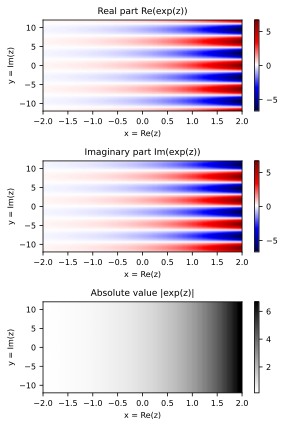

In [2]:
X, Y = np.meshgrid(np.arange(-2, 2, 0.1), np.arange(-12, 12, 0.1))
Z = X + Y*1j
f_exp = np.exp(Z)

plt.figure(figsize=(4.2, 6))
extent = [-2, 2, -12, 12]
plt.subplot(3, 1, 1)
plt.imshow(np.real(f_exp),  aspect='auto', cmap='seismic', origin='lower', extent=extent)
plt.title('Real part Re(exp(z))')
plt.xlabel('x = Re(z)')
plt.ylabel('y = Im(z)')
plt.colorbar()
plt.subplot(3, 1, 2)
plt.imshow(np.imag(f_exp),  aspect='auto', cmap='seismic', origin='lower', extent=extent)
plt.title('Imaginary part Im(exp(z))')
plt.xlabel('x = Re(z)')
plt.ylabel('y = Im(z)')
plt.colorbar()
plt.subplot(3, 1, 3)
plt.imshow(np.abs(f_exp),  aspect='auto', cmap='gray_r', origin='lower', extent=extent)
plt.title('Absolute value |exp(z)|')
plt.xlabel('x = Re(z)')
plt.ylabel('y = Im(z)')
plt.colorbar()
plt.tight_layout()

<a id='euler'></a> 
## Exponentiation Identity and Euler's Formula 

Based on the power series definition, one may prove two famous formulas of the exponential function that explain many of its properties. The first formula is knowns as **exponentiation identity** and says that 

$$
  \exp(z_1 + z_2) = \exp(z_1)\cdot \exp(z_2)
$$

for any complex numbers $z_1, z_2\in\mathbb{C}$. In particular, this property explains the exponential increase for real arguments. For example, 

$$
  \exp(n) = \exp(1+1+\ldots +1) = \exp(1)^n = e^n
$$

for $n\in\mathbb{N}$. The second famous formula, which is known as **Euler's formula**, relates the values of the exponential function at purely imaginary arguments to trigonometric functions. It states that for the complex (and purely imaginary) number $c = i\gamma$ with some real-valued $\gamma\in\mathbb{R}$ one has the identity 

$$\mathrm{exp}(i\gamma) = \cos(\gamma) + i\sin(\gamma) .$$

Actually, starting with the real sine and cosine functions, one often defines $\mathrm{exp}(i\gamma)$ by means of the Euler formula (rather than using the power series). This explains the periodic behavior of the real and imaginary part of $\exp$ along the imaginary (vertical) axis as shown in the previous figure. The real value $\gamma$ can be thought of as an angle (given in radians).  The following visualization shows how the values $\mathrm{exp}(i\gamma)$ change when increasing the angle $\gamma$ from $0$ to $2\pi$:

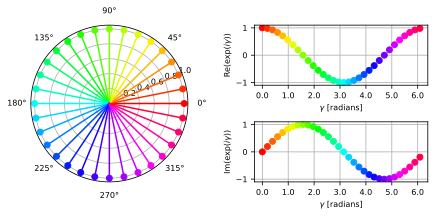

In [3]:
cmap = plt.get_cmap('hsv') # hsv is nice because it defines a circular color map

N = 32

fig = plt.figure(figsize=(6.2, 3))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1])

ax1 = fig.add_subplot(gs[:, 0], projection='polar')
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1])

for i in range(N):
    gamma = 2 * np.pi * i / N
    c = np.exp(1j * gamma)
    color = cmap(i / N)
    ax1.plot([0, np.angle(c)], [0, np.abs(c)], color=color)
    ax1.plot(np.angle(c), np.abs(c), 'o', color=color)
    ax2.plot(gamma, np.real(c), 'o', color=color)
    ax3.plot(gamma, np.imag(c), 'o', color=color)
    
ax2.grid()
ax2.set_xlabel(r'$\gamma$ [radians]')
ax2.set_ylabel(r'$\mathrm{Re}(\exp(i \gamma))$')
ax2.xaxis.set_major_formatter(ticker.FormatStrFormatter('$%s$')) 

ax3.grid()
ax3.set_xlabel(r'$\gamma$ [radians]')
ax3.set_ylabel(r'$\mathrm{Im}(\exp(i \gamma))$')
ax3.xaxis.set_major_formatter(ticker.FormatStrFormatter('$%s$')) 
plt.tight_layout()

We have seen from Euler's formula that the complex values $\mathrm{exp}(i\gamma)$ lie on the unit circle of the complex plane for all $\gamma\in\mathbb{R}$. Furthermore, due to periodicity, it suffices to consider $\gamma\in[0,2\pi)$. In fact, $\gamma$ encodes the angle (in radians) of the complex number $c = \mathrm{exp}(i\gamma)$, while $|c|=1$. From the exponentiation identity and Euler's formula, one can derive the following properties of the exponential function:

\begin{eqnarray*}
\exp(i\gamma) & = & \exp(i(\gamma+2\pi)) \\
|\exp(i\gamma)|  & = & 1 \\
\overline{\exp(i\gamma)} & = & \exp(-i\gamma) \\
\exp(i(\gamma_1+\gamma_2)) & = & \exp(i\gamma_1) \exp(i\gamma_2) \\
\end{eqnarray*}

Plugging in Euler's formula in the last identity, on obtains the trigonometric identities for the sine and cosine:

\begin{eqnarray*}
   \cos(\gamma_1+\gamma_2) &=&  \cos(\gamma_1)\cos(\gamma_2) - \sin(\gamma_1)\sin(\gamma_2)\\
   \sin(\gamma_1+\gamma_2) &=&  \cos(\gamma_1)\sin(\gamma_2) + \cos(\gamma_2)\sin(\gamma_1)
\end{eqnarray*}

<a id='differential'></a> 
## Differential Equations

The exponential function can be characterized by another important property in terms of differential equations. Let us consider the differential equation $\frac{df}{dx}(x)=f(x)$ with initial condition $f(0)=1$. The [**Picard&ndash;Lindelöf Theorem**](https://en.wikipedia.org/wiki/Picard%E2%80%93Lindel%C3%B6f_theorem) implies that there exists a unique solution. Using the power series definition, one can easily check that the exponential function indeed fulfills these properties. The differential equation also holds for the complex exponential function. In particular, one obtains the following equations:

\begin{eqnarray*}
\frac{d\exp(x)}{dx} & = & \exp(x)\\
\frac{d\exp(z)}{dz} & = & \exp(z)\\
\frac{d\exp(i\gamma)}{d\gamma} & = & i\exp(i\gamma)
\end{eqnarray*}

There are many numerical methods for approximating solutions of differential equations with initial conditions. The easiest method is known as **Euler's method**, where one starts with the initial value and then uses a tangent line over a short step size to estimate the function's value at the next step. In the next code cell, we implement this procedure for the case of the real exponential function. The figure shows the approximative solution compared to the NumPy function `np.exp`. To better understand the quality of the solution of the interval considered, we apply `plt.semilogy` for plotting.

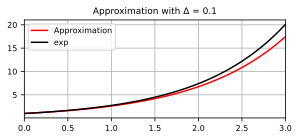

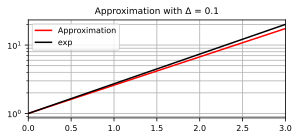

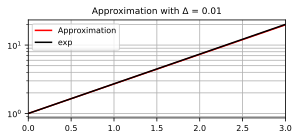

In [4]:
def exp_approx_Euler(x_min=0, x_max=2, x_delta=0.01, f_0=1):
    """Approximation of exponential function using Euler's method

    Notebook: PCP_07_exp.ipynb

    Args:
        x_min: Start of input interval (Default value = 0)
        x_max: End of input interval (Default value = 2)
        x_delta: Step size (Default value = 0.01)
        f_0: Initial condition (Default value = 1)

    Returns:
        f: Signal
        x: Sampled input interval
    """
    x = np.arange(x_min, x_max+x_delta, x_delta)
    N = len(x)
    f = np.zeros(N)
    f[0] = f_0
    for n in range(1, N):
        f[n] = f[n-1] + f[n-1]*x_delta
    return f, x


x_max = 3
x_delta = 0.1
f, x = exp_approx_Euler(x_min=0, x_max=x_max, x_delta=x_delta, f_0=1)

plt.figure(figsize=(4.2, 2))
plt.plot(x, f, 'r')
plt.plot(x, np.exp(x), 'k')
plt.legend(['Approximation','exp'])
plt.xlim([0, x_max])
plt.grid()
plt.title(r'Approximation with $\Delta$ = %.1f' % x_delta)
plt.tight_layout()

plt.figure(figsize=(4.2, 2))
plt.semilogy(x, f, 'r')
plt.semilogy(x, np.exp(x), 'k')
plt.legend(['Approximation','exp'])
plt.xlim([0, x_max])
plt.grid(which='both')
plt.title(r'Approximation with $\Delta$ = %.1f' % x_delta)
plt.tight_layout()

x_delta  = 0.01
f, x = exp_approx_Euler(x_min=0, x_max=x_max, x_delta=x_delta, f_0=1)
plt.figure(figsize=(4.2, 2))
plt.semilogy(x, f, 'r')
plt.semilogy(x, np.exp(x), 'k')
plt.legend(['Approximation','exp'])
plt.xlim([0, x_max])
plt.grid(which='both')
plt.title(r'Approximation with $\Delta$ = %.2f' % x_delta)
plt.tight_layout()

<a id='roots'></a> 
## Roots of Unity

Let $N \in \mathbb{N}_{>0}$ be a positive integer. A complex number $\rho \in \mathbb{C}$ is called an $N^\mathrm{th}$ **root of unity** if $\rho^N = 1$. It is not hard to see that there are exactly $N$ distinct $N^\mathrm{th}$ roots of unity, which are exactly the $N$ different roots of the polynomial $z^N-1$ (see also Exercise 2 of <a href="PCP_06_complex.html">Unit 6</a>). Additionally, if $\rho^n \neq 1$ for all $n\in [1:N-1]$, the root $\rho$ is called a **primitive** $N^\mathrm{th}$ root of unity. With the properties mentioned above, it is easy to see that $\rho_N:=\exp(2 \pi i / N)$ is such a **primitive** $N^\mathrm{th}$ root of unity. Furthermore, all $N^\mathrm{th}$ roots of unity can be generated by considering the powers of $\rho_N$:

$$1=\rho_N^0, \quad \rho_N^1, \quad \rho_N^2, \quad ...,\quad \rho_N^{N-1}$$

The following plot shows all roots of unity for different integers $N \in \mathbb{N}_{>0}$. The primitive roots are indicated in red. 

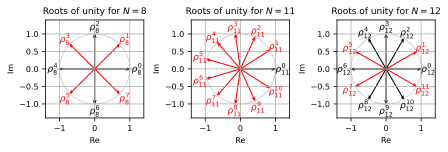

In [5]:
def plot_vector(c, color='k', start=0, linestyle='-'):
    """Plotting complex number as vector

    Notebook: PCP_07_exp.ipynb

    Args:
        c: Complex number
        color: Vector color (Default value = 'k')
        start: Start of vector (Default value = 0)
        linestyle: Line Style of vector (Default value = '-')
    """
    return plt.arrow(np.real(start), np.imag(start), np.real(c), np.imag(c),
                     linestyle=linestyle, head_width=0.05,
                     fc=color, ec=color, overhang=0.3, length_includes_head=True)


def plot_root_unity(N, ax):
    """Plotting N-th root of unity into figure with axis

    Notebook: PCP_07_exp.ipynb

    Args:
        N: Root number
        ax: Axis handle
    """
    root_unity = np.exp(2j * np.pi / N)
    root_unity_power = 1

    ax.grid()
    ax.set_xlim([-1.4, 1.4])
    ax.set_ylim([-1.4, 1.4])
    ax.set_xlabel(r'$\mathrm{Re}$')
    ax.set_ylabel(r'$\mathrm{Im}$')
    ax.set_title('Roots of unity for $N=%d$' % N)

    for n in range(0, N):
        colorPlot = 'r' if gcd(n, N) == 1 else 'k'
        plot_vector(root_unity_power, color=colorPlot)
        ax.text(np.real(1.2*root_unity_power), np.imag(1.2*root_unity_power),
                r'$\rho_{%s}^{%s}$' % (N, n), size='9',
                color=colorPlot, ha='center', va='center')
        root_unity_power *= root_unity

    circle_unit = plt.Circle((0, 0), 1, color='lightgray', fill=0)
    ax.add_artist(circle_unit)
    ax.set_aspect('equal')

plt.figure(figsize=(6.2, 3))
ax = plt.subplot(1, 3, 1)
plot_root_unity(N=8, ax=ax)    
ax = plt.subplot(1, 3, 2)
plot_root_unity(N=11, ax=ax)
ax = plt.subplot(1, 3, 3)
plot_root_unity(N=12, ax=ax)
plt.tight_layout()

<a id='exercise_approx_exp'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 1: Approximation of Exponential Function via Power Series</strong>
<p style="color:#006064;">
Implement a function <code>exp_power_series</code> with input arguments $z\in\mathbb{C}$ and $N\in\mathbb{N}$, which outputs an approximation $\sum_{n=0}^{N} \frac{z^n}{n!}$ of $\exp(z)$. Similarly, implement a function <code>exp_limit_compound</code> that approximates $\exp(z)$ via $\left(1+\frac{z}{N}\right)^{N}$. Test the two functions for various input arguments and compare the results with the NumPy function <code>np.exp</code>. In particular, compare the approximation quality of <code>exp_power_series</code> and <code>exp_limit_compound</code> for increasing $N$ (fixing a complex number $z$).
</p>
</div>

In [6]:
# Your Solution

In [7]:
exercise_approx_exp()

Input argument z = 1
N=  1, Numpy=2.7182818285, Approx1=2.0000000000, Approx2=2.0000000000
N=  2, Numpy=2.7182818285, Approx1=2.5000000000, Approx2=2.2500000000
N=  4, Numpy=2.7182818285, Approx1=2.7083333333, Approx2=2.4414062500
N=  8, Numpy=2.7182818285, Approx1=2.7182787698, Approx2=2.5657845140
N= 16, Numpy=2.7182818285, Approx1=2.7182818285, Approx2=2.6379284974
N= 32, Numpy=2.7182818285, Approx1=2.7182818285, Approx2=2.6769901294

Input argument z = (2.0, 0.7)
N=  1, Numpy=(5.6515, 4.7602), Approx1=(3.0000, 0.7000), Approx2=(3.0000, 0.7000)
N=  2, Numpy=(5.6515, 4.7602), Approx1=(4.7550, 2.1000), Approx2=(3.8775, 1.4000)
N=  4, Numpy=(5.6515, 4.7602), Approx1=(5.7850, 4.2618), Approx2=(4.6500, 2.3303)
N=  8, Numpy=(5.6515, 4.7602), Approx1=(5.6544, 4.7601), Approx2=(5.1527, 3.2239)
N= 16, Numpy=(5.6515, 4.7602), Approx1=(5.6515, 4.7602), Approx2=(5.4157, 3.8820)
N= 32, Numpy=(5.6515, 4.7602), Approx1=(5.6515, 4.7602), Approx2=(5.5401, 4.2885)
N= 64, Numpy=(5.6515, 4.7602), Appro

<a id='exercise_gaussian'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 2: Gaussian Function</strong>
<p style="color:#006064;">
<a href="https://en.wikipedia.org/wiki/Gaussian_function ">Gaussian functions</a> are often used in statistics to represent the probability density function of a normally distributed random variable with expected value $\mu$ and variance $\sigma^2$. For these parameters, the Gaussian function $g:\mathbb{R}\to \mathbb{R}$ is defined by
$$
   g(x):= \frac{1}{\sigma\sqrt{2\pi}}  \exp\left(-\frac{1}{2} \left(\frac{x-\mu}{\sigma} \right)^2 \right).
$$
Using <code>np.exp</code>, implement a function <code>compute_gaussian_1D</code> that inputs a NumPy array <code>X</code> (as well as input arguments for $\mu$ and $\sigma$) and evaluates the Gaussian function <code>X</code> in a point-wise fashion. Plot the result for an input vector and various choices of $\mu$ and $\sigma$.
</p>
</div>

In [8]:
# Your Solution

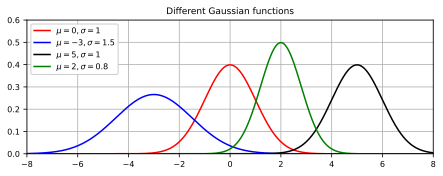

In [9]:
exercise_gaussian()

<a id='exercise_spiral'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 3: Spiral  Generation</strong>
<p style="color:#006064;">
Implement a function <code>generate_spiral</code> that generates a spiral of increasing radius (Hint: Make use of the exponential function). The function should have the following arguments:
</p>
<ul style="color:#006064;">
    <li><code>rad_start</code>: Radius to start with</li>
    <li><code>rad_end</code>: Radius to stop with</li>
    <li><code>num_rot</code>: Number of rotations</li>
    <li><code>angle_start</code>: Angle to start with (given in degrees)</li>
    <li><code>N</code>: Number of data points to represent the spiral</li>
</ul>
<p style="color:#006064;">
Plot the spiral for various parameters.
</p>
</div>

In [10]:
# Your Solution

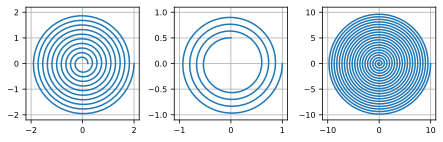

In [11]:
exercise_spiral()

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCP_License.png" width=100% style="float: right;" alt="PCP License"></a>
</div>